In [45]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Load the Employee Attrition dataset

In [46]:
df=pd.read_csv("HR_Employee_Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


Step 2:perform EDA

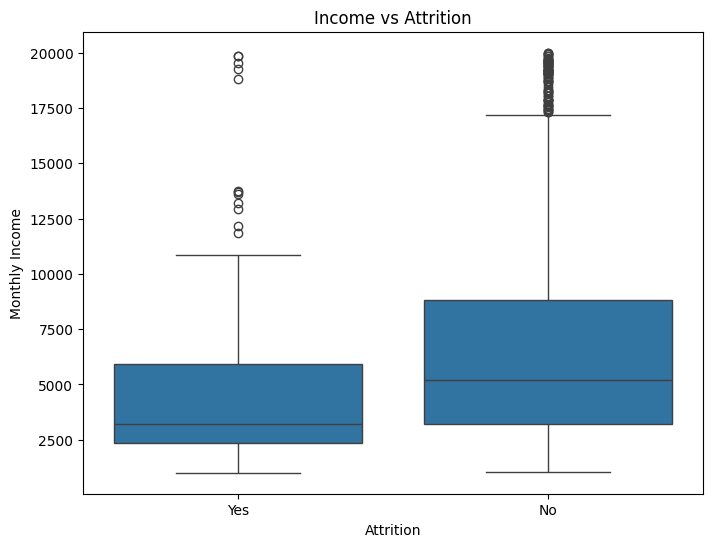

In [47]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Attrition",y="MonthlyIncome",data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

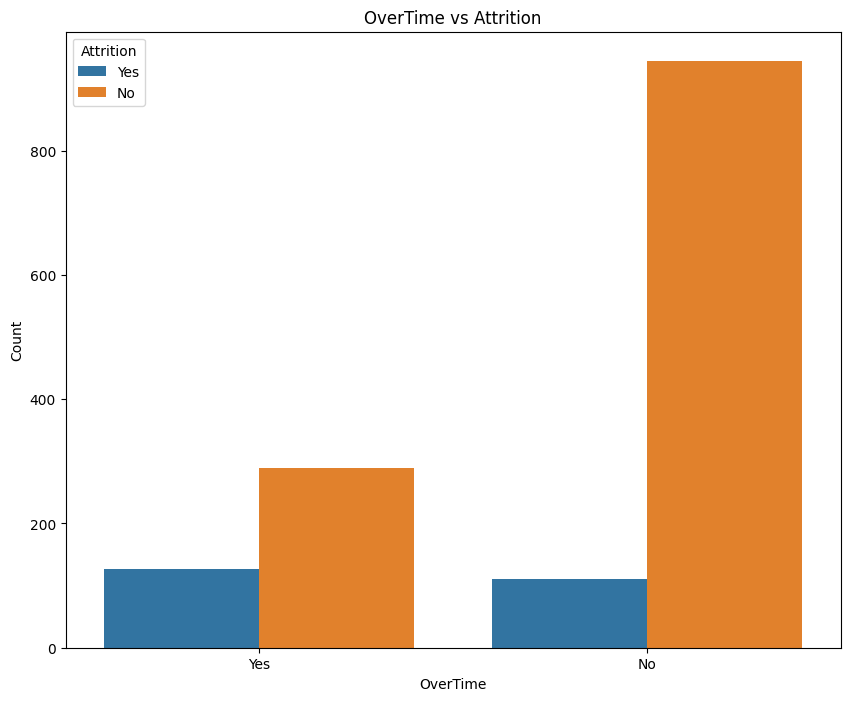

In [48]:
plt.figure(figsize=(10,8))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

Step 3:Data Preprocessing

In [49]:
df.drop(["EmployeeNumber","EmployeeCount","Over18","StandardHours"],axis=1,inplace=True)

lb=LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col]=lb.fit_transform(df[col])

x=df.drop("Attrition",axis=1)
y=df["Attrition"]


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=42)

Step 4:Modelling and Tunning

In [50]:
rf=RandomForestClassifier(random_state=42)

param_grid={
    "n_estimators":[50,100],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2],
}
grid_search = GridSearchCV(rf,param_grid,cv=5,scoring='f1')
grid_search.fit(x_train,y_train)

print("Best Hyperparameters:",grid_search.best_params_)

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Step 5:  Best Model

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       507
           1       0.81      0.16      0.27        81

    accuracy                           0.88       588
   macro avg       0.85      0.58      0.60       588
weighted avg       0.87      0.88      0.84       588

[[504   3]
 [ 68  13]]


Text(0, 0.5, 'feature')

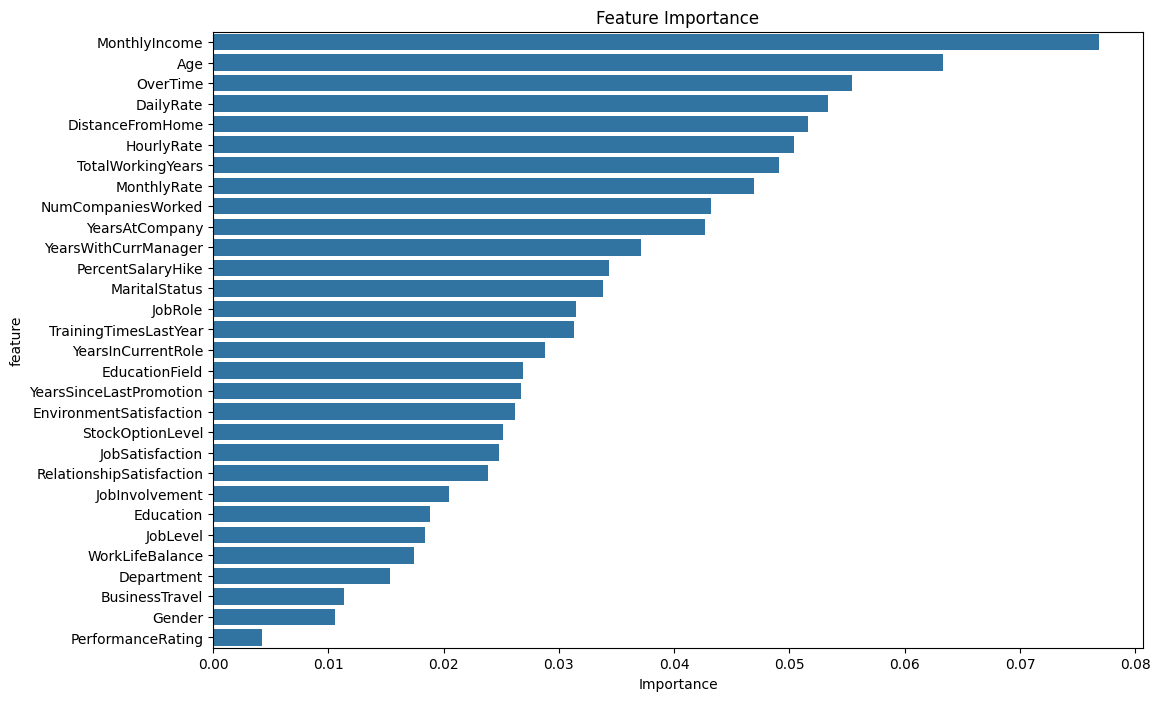

In [51]:
best_model=grid_search.best_estimator_
predections=best_model.predict(x_test)
print(classification_report(y_test,predections))
print(confusion_matrix(y_test,predections))

importances=best_model.feature_importances_
feature_importance_df=pd.DataFrame({
    "Feature":x.columns,
    "Importance":importances
}).sort_values(by="Importance",ascending=False)
plt.figure(figsize=(12,8))
sns.barplot(x="Importance",y="Feature",data=feature_importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("feature")

Step 6: Saving the Model

In [55]:
model=RandomForestClassifier(**grid_search.best_params_,random_state=42)
model.fit(x,y)

joblib.dump(model,"employee_attrition_model.pk1")
joblib.dump(lb,"label_encoder.pk1")
joblib.dump(x.columns.to_list(),"feature_columns.pk1")


['feature_columns.pk1']